# Sort spot clean playground

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.filters as flt
import sys

sys.path.append('../../build-imagingsuite/Release/lib/')
import imgalg as ia

sys.path.append('../../scripts/python')
import amglib.readers as rd


In [78]:
ss = ia.SortSpotClean(True,16,False)

In [79]:
# img = rd.read_image('/Users/Shared/Data/P20241355/02_rawdata/01_data/h2o_5s_00003.fits')
img= rd.read_image('../../TestData/2D/tiff/spots/balls.tif')
# img= rd.read_image('../../TestData/2D/tiff/manyspots.tif')


Process 2D: py::array_t<float> &x, float th, float sigma


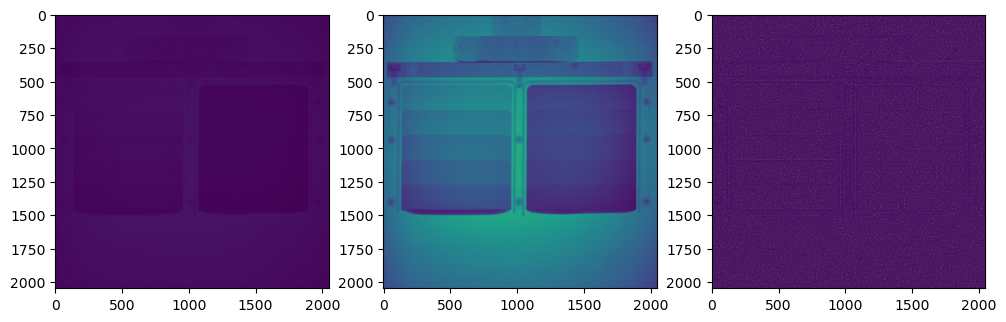

In [92]:
img2 = np.copy(img).astype('float32')
ss.process(img2,quantile=0.97,th=3,method=ia.eSortSpotQuantile.SortQuantileBright)

fig,ax = plt.subplots(1,3,figsize=[12,4])
ax[0].imshow(img)
ax[1].imshow(img2)
ax[2].imshow(img-img2,vmin=-1,vmax=20)

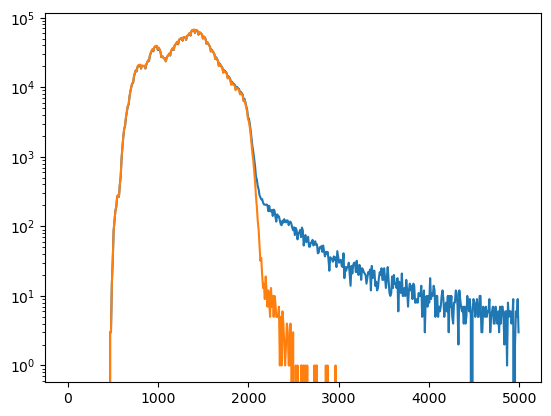

In [87]:
h0=np.histogram(img.ravel(),bins=np.linspace(0,5000,512));
h1=np.histogram(img2.ravel(),bins=np.linspace(0,5000,512));

plt.semilogy(h0[1][:-1],h0[0])
plt.semilogy(h1[1][:-1],h1[0])

In [83]:
mimg = flt.median(img, footprint=np.ones([7,7]))